# Inhalt aus: `B410-xg-cancer.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Supervised Learning - XGBoost - Cancer
</b></font> </br></p>

---


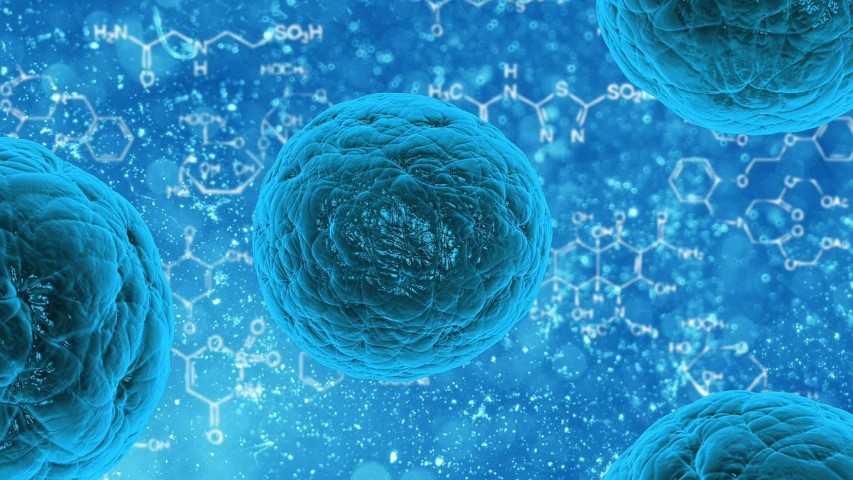

Bild von <a href="https://pixabay.com/de/users/publicdomainpictures-14/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">PublicDomainPictures</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install
!uv pip install --system -q dtreeviz

In [ ]:
# Import
from pandas import read_csv, DataFrame

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.decomposition import PCA

from xgboost.sklearn import XGBClassifier

import dtreeviz

import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings

warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




**Beschreibung:**   
Diese Arbeit entstand aus dem Wunsch, Gewebeproben ausschließlich auf der Grundlage einer Feinnadelpunktion (FNA) genau zu diagnostizieren. In Zusammenarbeit mit Prof. Mangasarian und zwei seiner Doktoranden, Rudy Setiono und Kristin Bennett , wurde mithilfe der Multisurface-Methode (MSM) zur Mustertrennung dieser neun Merkmale ein Klassifikator erstellt, der 97 % der neuen Fälle erfolgreich diagnostizierte. Der resultierende Datensatz ist als Wisconsin Breast Cancer Data bekannt.


Die Arbeit an der Bildanalyse begann 1990 mit der Aufnahme von Nick Street in das Forschungsteam. Ziel war es, die Probe anhand eines digitalen Bildes eines kleinen Abschnitts des FNA-Objektträgers zu diagnostizieren.

**Diagnoseablauf:**

Es wird aus dem Gewebe eine FNA entnommen. Dieses Material wird dann auf einen Objektträger montiert und gefärbt, um die Zellkerne hervorzuheben. Ein Teil des Objektträgers, in dem die Zellen gut differenziert sind, wird dann mit einer Digitalkamera und einem Framegrabber-Board gescannt.
Anschließend isoliert der Anwender die einzelnen Zellkerne . Mit einem Mauszeiger zeichnet der Benutzer die ungefähre Grenze jedes Kerns. Mithilfe eines Computer-Vision-Ansatzes, konvergieren diese Annäherungen dann an die genauen nuklearen Grenzen. Sobald alle (oder die meisten) Kerne auf diese Weise isoliert wurden, berechnet das Programm Werte für jedes der zehn Merkmale jedes Kerns und misst Größe, Form und Textur. Der Mittelwert, der Standardfehler und die Extremwerte dieser Merkmale werden berechnet, was zu insgesamt 30 Kernmerkmalen für jede Probe führt.

[DataSet](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

[Info](https://pages.cs.wisc.edu/~olvi/uwmp/cancer.html)

**Wertebereich: 1 – 10**      
+ 1 = eher unauffällig / typisch gutartig        

+ 10 = stark auffällig / typisch bösartig



**Features:**


+ Dicke: 1 - 10
+ Einheitlichkeit der Zellgröße: 1 - 10
+ Gleichmäßigkeit der Zellform: 1 - 10
+ Randhaftung: 1 - 10
+ Größe einzelner Epithelzellen: 1 - 10
+ Nackte Kerne: 1 - 10
+ Blandes Chromatin: 1 - 10
+ Normale Nukleolen: 1 - 10
+ Mitosen: 1 - 10

**Klassen:**

+ Klasse: (2 für gutartig, 4 für bösartig)

**Kurzerläuterung:**

| **Merkmal**                           | **Erläuterung (einfach und verständlich)**                                                                            |
| ------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **Dicke** *(Clump Thickness)*         | Wie dick oder dicht gepackt die Zellverbände sind – dicker = potenziell auffälliger                                   |
| **Einheitlichkeit der Zellgröße**     | Wie ähnlich oder unterschiedlich die Zellgrößen sind – starke Unterschiede können auf Bösartigkeit hinweisen          |
| **Gleichmäßigkeit der Zellform**      | Wie regelmäßig die Zellformen sind – unregelmäßige Formen sind oft verdächtig                                         |
| **Randhaftung** *(Marginal Adhesion)* | Wie gut haften die Zellen aneinander – geringe Haftung kann auf bösartige Zellen hindeuten                            |
| **Größe einzelner Epithelzellen**     | Durchschnittliche Größe bestimmter Zellen – ungewöhnlich große Zellen können ein Risikozeichen sein                   |
| **Nackte Kerne** *(Bare Nuclei)*      | Zellkerne, die außerhalb von Zellen sichtbar sind – in größerer Zahl ein typisches Merkmal bösartiger Tumoren         |
| **Blandes Chromatin**                 | Wie gleichmäßig die DNA-Struktur im Zellkern aussieht – „bland“ heißt einheitlich, Abweichungen können auffällig sein |
| **Normale Nukleolen**                 | Nukleolen = Zellkernbestandteile – viele oder große Nukleolen sind oft in bösartigen Zellen zu finden                 |
| **Mitosen**                           | Zellteilungen – viele Mitosen deuten auf schnelles Zellwachstum hin, was ein Warnzeichen sein kann                    |


In [ ]:
import pandas as pd
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/breast_cancer_wisconsin.csv')

In [ ]:
data = df.copy()
target = data.pop("Class")

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Datentyp
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Missing Values
</font></p>

In [ ]:
data = data.dropna()

In [ ]:
target = target.loc[data.index]

<p><font color='black' size="5">
Kodieren Target auf 0/1
</font></p>

In [ ]:
target.replace([2, 4], [0, 1], inplace=True)

<p><font color='black' size="5">
Skalieren
</font></p>

In [ ]:
scaler = MinMaxScaler()
data[num_col] = scaler.fit_transform(data[num_col])

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.30, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>



[Doku](https://xgboost.readthedocs.io/en/stable/index.html#)    
[Parameter](https://xgboost.readthedocs.io/en/latest/parameter.html)

In [ ]:
model = XGBClassifier(random_state = 42)

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---

<p><font color='black' size="5">
🔭 Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

In [ ]:
# Wahrscheinlichkeiten prognostizieren
target_train_pred_prob = model.predict_proba(data_train)
target_test_pred_prob = model.predict_proba(data_test)

<p><font color='black' size="5">
📱 Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred)
display_labels_ = ["gutartig", "bösartig"]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap="Blues")

In [ ]:
print(
    classification_report(target_test, target_test_pred, target_names=display_labels_)
)

<p><font color='black' size="5">
🎯 Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}%")

<p><font color='black' size="5">
✨Feature Importance
</font></p>

In [ ]:
px.bar(
    x=model.feature_importances_, y=data.columns, width=1000, height=700
).update_yaxes(categoryorder="total ascending")

<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

# Übernahme Target real & predict
cube["real"] = DataFrame(target_test.values, columns=["real"])
cube["predict"] = DataFrame(target_test_pred, columns=["predict"])

<p><font color='black' size="5">
Visualisierung real vs predict
</font></p>

In [ ]:
# Histogramm
title_ = "Histogramm real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=2, text_auto=".2s", title=title_)
fig.update_layout(barmode="group", bargap=0.1, width=600, height=600)
fig.show()

In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

In [ ]:
cube[cube.real != cube.predict]

<p><font color='black' size="5">
Entscheidungsbaum
</font></p>

In [ ]:
viz_model = dtreeviz.model(
    model,
    data_test,
    target_test,
    tree_index=1,
    target_name="target",
    feature_names=list(data.columns.values),
    class_names=["No", "Yes"],
)

In [ ]:
viz_model.view(scale=1.5, fontname="Monospace")

In [ ]:
viz_model.view(scale=1.5, orientation="LR", fontname="Monospace")

In [ ]:
# local Explanation
one = data_test.iloc[13]
viz_model.view(x=one, fontname="Monospace")

In [ ]:
# local Explanation
viz_model.view(x=one, show_just_path=True, fontname="Monospace")

In [ ]:
print(viz_model.explain_prediction_path(one))

In [ ]:
tree_img = viz_model.view(scale=0.8, fontname="Monospace")
tree_img.save("tree.svg")

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B430-stacking-titanic.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Ensemble - Stacking 3+1 - Titanic
</b></font> </br></p>

---


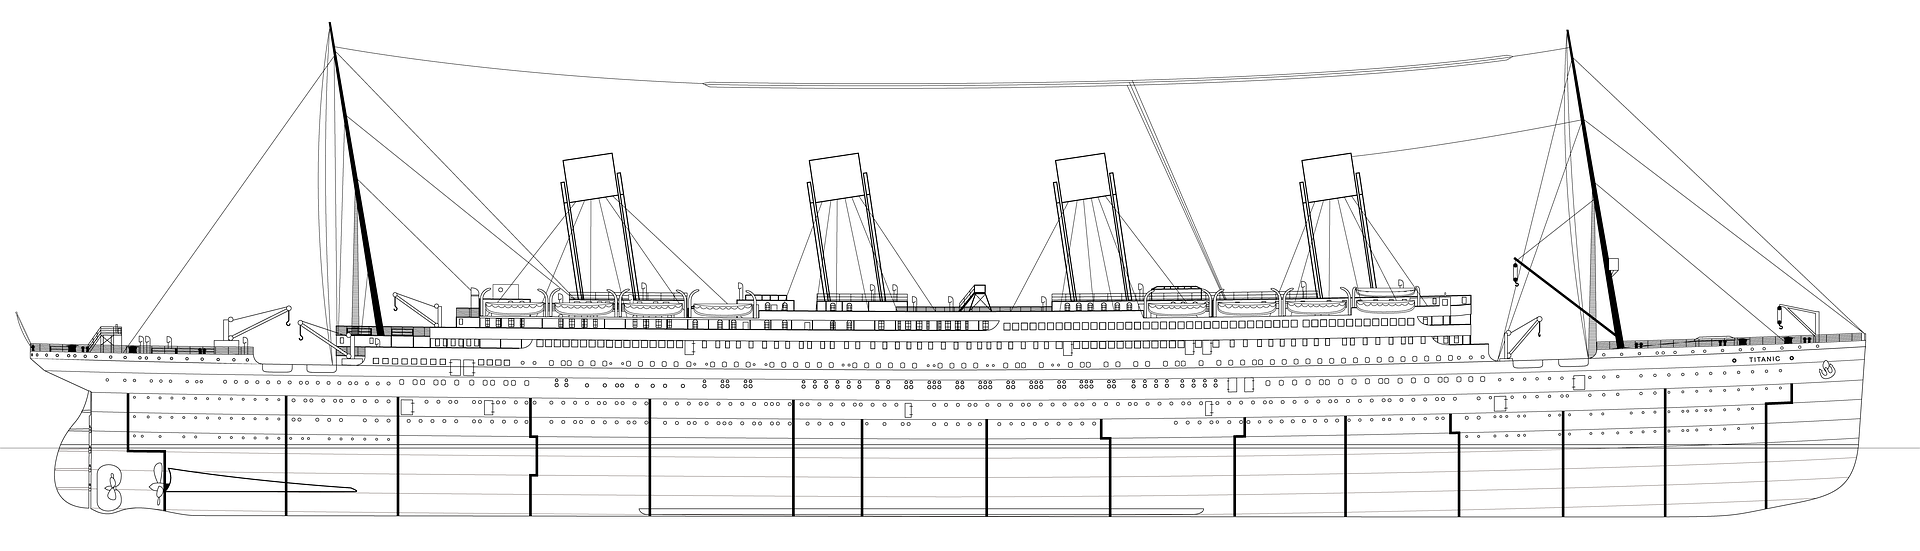

Bild von <a href="https://pixabay.com/de/users/axonia-14892766/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">axonia</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Ordinalcoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

Dies ist der legendäre Titanic ML-Wettbewerb – die beste erste Herausforderung, um in ML-Modellierung einzutauchen.

Die Aufgabe ist einfach: Verwenden Sie maschinelles Lernen, um ein Modell zu erstellen, das vorhersagt, welche Passagiere den Schiffbruch der Titanic überlebt haben.

[Titanic Org](https://www.encyclopedia-titanica.org/)

[DataSet](https://www.openml.org/search?type=data&status=active&id=40945)

[Info](https://www.kaggle.com/competitions/titanic/data)



In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Titanic.csv",
    usecols=["pclass", "survived", "sex", "age", "sibsp", "parch"],
)

In [ ]:
data = df.copy()
target = data.pop("survived")

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.groupby("pclass").count()

In [ ]:
target.value_counts()

In [ ]:
# _ = data.hist(figsize=(15,15))

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Missing Values
</font></p>

In [ ]:
mv = data.isnull().sum()
mv_col = list(mv[mv > 0].index)

In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
data[mv_col] = DataFrame(imputer.fit_transform(data[mv_col]))

<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
coder = Ordinalcoder()
data[cat_col] = coder.fit_transform(data[cat_col])

<p><font color='black' size="5">
Skalierung
</font></p>

In [ ]:
scaler = MinMaxScaler()
data[num_col] = scaler.fit_transform(data[num_col])

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.30, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
Aufbau Ensemble
</font></p>

In [ ]:
estimators = [
    ("rf", RandomForestClassifier(n_estimators=10, random_state=42)),
    ("knn", KNeighborsClassifier()),
    ("svc", LinearSVC(random_state=42)),
]

In [ ]:
model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)


<p><font color='black' size="5">
Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print(f"-- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print(f"-- Test -- Accuracy: {acc_test:5.2f}")


<p><font color='black' size="5">
Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["Not Survived", "Survived"])
disp.plot(cmap="Blues")

In [ ]:
print(
    classification_report(
        target_test, target_test_pred, target_names=["Not Survived", "Survived"]
    )
)

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `template.ipynb`
---

#  0 | Install & Import

In [ ]:
# Install


In [ ]:
# Import


In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

#  1 | Understand

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

#  2 | Prepare

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

#  3 | Modeling

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

#  4 | Evaluate

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

#  5 | Deploy

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>